In [1]:
import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 重新拉取沪深300成分股收盘价
hs300 = ak.index_stock_cons_weight_csindex(symbol="000300")
stock_list = hs300["成分券代码"].tolist()

close_dict = {}
for i, code in enumerate(stock_list):
    try:
        df = ak.stock_zh_a_hist(symbol=code, adjust="qfq",
                                start_date="2023-01-01")
        close_dict[code] = df.set_index("日期")["收盘"]
        if i % 50 == 0:
            print(f"进度：{i}/300")
    except:
        continue

close_df = pd.DataFrame(close_dict)
close_df.index = pd.to_datetime(close_df.index)
close_df = close_df[close_df.index >= "2023-01-01"]
close_df = close_df.dropna(axis=1, thresh=len(close_df)*0.9)

print(f"\n数据加载完成：{close_df.shape}")

进度：0/300
进度：50/300
进度：100/300
进度：150/300
进度：200/300
进度：250/300

数据加载完成：(781, 296)


In [2]:
# 存成CSV，以后直接读本地
close_df.to_csv("close_data.csv")
print("已保存到 close_data.csv")

已保存到 close_data.csv


In [3]:
close_df = pd.read_csv("close_data.csv", index_col=0, parse_dates=True)

In [4]:
# 计算三个因子
momentum = close_df / close_df.shift(20) - 1
reversal = -(close_df / close_df.shift(5) - 1)

# 拉取换手率数据
volume_dict = {}
for i, code in enumerate(close_df.columns):
    try:
        df = ak.stock_zh_a_hist(symbol=code, adjust="qfq",
                                start_date="2023-01-01")
        volume_dict[code] = df.set_index("日期")["换手率"]
        if i % 50 == 0:
            print(f"进度：{i}/{len(close_df.columns)}")
    except:
        continue

volume_df = pd.DataFrame(volume_dict)
volume_df.index = pd.to_datetime(volume_df.index)
volume_df = volume_df[volume_df.index >= "2023-01-01"]
volume_df.to_csv("volume_data.csv")
print("换手率数据已保存")

进度：0/296
进度：50/296
进度：100/296
进度：150/296
进度：200/296
进度：250/296
换手率数据已保存


In [5]:
# 标准化函数
def standardize(factor):
    return (factor - factor.mean(axis=1).values.reshape(-1,1)) / \
            factor.std(axis=1).values.reshape(-1,1)

# 三因子标准化
mom_std = standardize(momentum)
rev_std = standardize(reversal)

volume_df2 = pd.read_csv("volume_data.csv", index_col=0, parse_dates=True)
turnover_factor = -volume_df2.rolling(20).mean()
turn_std = standardize(turnover_factor)

# 等权合成
combined = (mom_std + rev_std + turn_std) / 3

# 每月第一个交易日调仓，选因子排名前20%的股票
def get_selected_stocks(factor_row, top_pct=0.2):
    valid = factor_row.dropna()
    n = max(int(len(valid) * top_pct), 1)
    return valid.nlargest(n).index.tolist()

print("合成因子计算完成")
print(f"因子维度：{combined.shape}")

合成因子计算完成
因子维度：(781, 296)


In [7]:
# 回测参数
rebalance_freq = 20      # 每20个交易日调仓一次
top_pct = 0.2            # 选前20%的股票
cost = 0.002             # 每次交易成本0.2%

# 初始化
portfolio_value = [1.0]  # 初始净值为1
current_stocks = []      # 当前持仓

# 找到所有调仓日（每20个交易日）
dates = combined.index.tolist()
rebalance_dates = dates[20::rebalance_freq]

for i, date in enumerate(dates[20:], start=20):
    # 调仓日：重新选股
    if date in rebalance_dates:
        factor_row = combined.loc[date]
        current_stocks = get_selected_stocks(factor_row, top_pct)

    # 计算当天组合收益
    if len(current_stocks) == 0:
        portfolio_value.append(portfolio_value[-1])
        continue

    # 持仓股票当天的等权收益
    prev_date = dates[i-1]
    returns = []
    for code in current_stocks:
        if code in close_df.columns:
            try:
                r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                if not np.isnan(r):
                    returns.append(r)
            except:
                continue

    if len(returns) == 0:
        portfolio_value.append(portfolio_value[-1])
        continue

    daily_return = np.mean(returns)

    # 调仓日扣除交易成本
    if date in rebalance_dates:
        daily_return -= cost

    portfolio_value.append(portfolio_value[-1] * (1 + daily_return))

portfolio = pd.Series(portfolio_value, index=dates[20-1:])
print(f"回测完成，最终净值：{portfolio.iloc[-1]:.4f}")

回测完成，最终净值：1.0856


累计收益：8.56%
年化收益：2.75%
最大回撤：-22.73%
Sharpe Ratio：0.2423


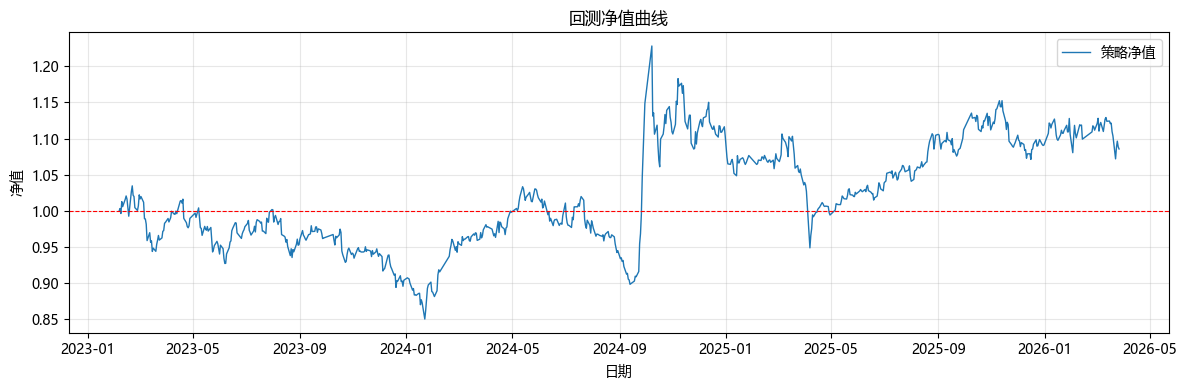

In [8]:
# 计算关键指标
total_return = portfolio.iloc[-1] - 1
days = len(portfolio)
annual_return = (1 + total_return) ** (252/days) - 1

# 最大回撤
rolling_max = portfolio.cummax()
drawdown = (portfolio - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Sharpe Ratio
daily_returns = portfolio.pct_change().dropna()
sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)

print(f"累计收益：{total_return:.2%}")
print(f"年化收益：{annual_return:.2%}")
print(f"最大回撤：{max_drawdown:.2%}")
print(f"Sharpe Ratio：{sharpe:.4f}")

# 画净值曲线
plt.figure(figsize=(12, 4))
plt.plot(portfolio.index, portfolio, linewidth=1, label="策略净值")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("回测净值曲线")
plt.xlabel("日期")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 拉取沪深300指数数据
hs300_index = ak.stock_zh_index_daily(symbol="sh000300")
hs300_index["date"] = pd.to_datetime(hs300_index["date"])
hs300_index = hs300_index.set_index("date")
hs300_index = hs300_index[hs300_index.index >= portfolio.index[0]]

# 归一化到1，方便和策略净值对比
hs300_norm = hs300_index["close"] / hs300_index["close"].iloc[0]

print(f"沪深300数据：{hs300_norm.shape}")
print(hs300_norm.tail())

沪深300数据：(762,)
date
2026-03-23    1.081020
2026-03-24    1.094900
2026-03-25    1.110252
2026-03-26    1.095588
2026-03-27    1.101714
Name: close, dtype: float64


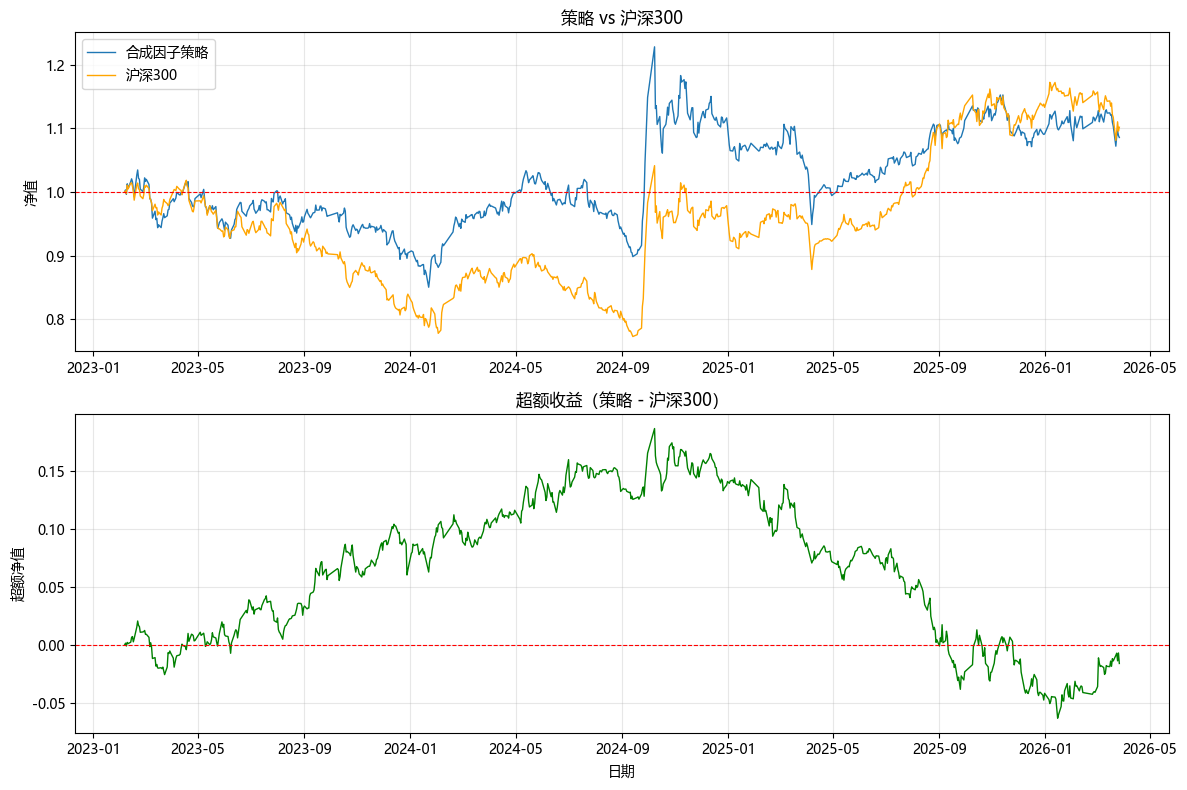

策略累计收益：8.56%
沪深300累计收益：10.17%
超额收益：-1.61%


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 上图：净值对比
ax1.plot(portfolio.index, portfolio, linewidth=1, label="合成因子策略")
ax1.plot(hs300_norm.index, hs300_norm, linewidth=1, label="沪深300", color="orange")
ax1.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
ax1.set_title("策略 vs 沪深300")
ax1.set_ylabel("净值")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 下图：超额收益（策略 - 沪深300）
# 对齐两个序列的日期
common_dates = portfolio.index.intersection(hs300_norm.index)
excess = portfolio[common_dates] - hs300_norm[common_dates]
ax2.plot(common_dates, excess, linewidth=1, color="green")
ax2.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax2.set_title("超额收益（策略 - 沪深300）")
ax2.set_ylabel("超额净值")
ax2.set_xlabel("日期")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印对比指标
hs300_return = hs300_norm.iloc[-1] - 1
print(f"策略累计收益：{total_return:.2%}")
print(f"沪深300累计收益：{hs300_return:.2%}")
print(f"超额收益：{total_return - hs300_return:.2%}")

In [11]:
# 找出2024年9月附近净值变化最大的几天
portfolio_returns = portfolio.pct_change().dropna()
suspicious = portfolio_returns["2024-08-01":"2024-10-01"].sort_values(ascending=False)
print("2024年8-10月单日涨幅最大的几天：")
print(suspicious.head(10))

2024年8-10月单日涨幅最大的几天：
2024-09-30    0.097701
2024-09-27    0.050824
2024-09-24    0.041930
2024-09-26    0.028025
2024-09-25    0.014605
2024-09-23    0.007966
2024-09-19    0.007427
2024-08-15    0.007241
2024-09-18    0.005017
2024-08-23    0.003881
dtype: float64


In [12]:
# 看沪深300指数当天的真实涨幅
hs300_returns = hs300_norm.pct_change().dropna()
print("沪深300同期单日涨幅：")
print(hs300_returns["2024-08-01":"2024-10-01"].sort_values(ascending=False).head(10))

沪深300同期单日涨幅：
date
2024-09-30    0.084826
2024-09-27    0.044669
2024-09-24    0.043310
2024-09-26    0.042271
2024-09-25    0.014805
2024-08-30    0.013348
2024-08-15    0.009886
2024-09-19    0.007892
2024-08-23    0.004242
2024-09-18    0.003723
Name: close, dtype: float64


In [13]:
# 看尖峰之后的回落
print("2024年10月之后的单日跌幅：")
print(portfolio_returns["2024-10-01":"2024-12-31"].sort_values().head(10))

2024年10月之后的单日跌幅：
2024-10-09   -0.078904
2024-11-22   -0.034148
2024-10-11   -0.025969
2024-10-15   -0.025404
2024-12-13   -0.023589
2024-11-15   -0.021552
2024-11-14   -0.020860
2024-10-16   -0.018186
2024-11-28   -0.015412
2024-10-29   -0.012952
dtype: float64


In [14]:
print("沪深300同期跌幅：")
print(hs300_returns["2024-10-01":"2024-12-31"].sort_values().head(5))

沪深300同期跌幅：
date
2024-10-09   -0.070513
2024-11-22   -0.030983
2024-10-11   -0.027671
2024-10-15   -0.026594
2024-12-13   -0.023662
Name: close, dtype: float64


In [15]:
# 计算沪深300的200日均线
hs300_close = hs300_index["close"]
hs300_ma200 = hs300_close.rolling(200).mean()

# 重新回测（加入风控）
portfolio_value2 = [1.0]
current_stocks = []

for i, date in enumerate(dates[20:], start=20):
    prev_date = dates[i-1]
    
    # 风控规则一：沪深300跌破200日均线，空仓
    if date in hs300_close.index and date in hs300_ma200.index:
        if hs300_close.loc[date] < hs300_ma200.loc[date]:
            portfolio_value2.append(portfolio_value2[-1])
            current_stocks = []
            continue

    # 调仓日重新选股
    if date in rebalance_dates:
        factor_row = combined.loc[date]
        current_stocks = get_selected_stocks(factor_row, top_pct)

    if len(current_stocks) == 0:
        portfolio_value2.append(portfolio_value2[-1])
        continue

    # 计算当天收益
    returns = []
    for code in current_stocks:
        if code in close_df.columns:
            try:
                r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                if not np.isnan(r):
                    returns.append(r)
            except:
                continue

    if len(returns) == 0:
        portfolio_value2.append(portfolio_value2[-1])
        continue

    daily_return = np.mean(returns)

    # 风控规则二：单日亏损超过3%，强制平仓
    if daily_return < -0.03:
        daily_return = -0.03
        current_stocks = []

    if date in rebalance_dates:
        daily_return -= cost

    portfolio_value2.append(portfolio_value2[-1] * (1 + daily_return))

portfolio2 = pd.Series(portfolio_value2, index=dates[19:])
print(f"加入风控后最终净值：{portfolio2.iloc[-1]:.4f}")

加入风控后最终净值：1.1675


加风控前 vs 加风控后：
                       原策略        加风控
累计收益                 8.56%     16.75%
年化收益                 2.75%      5.26%
最大回撤               -22.73%    -15.06%
Sharpe              0.2423     0.4341


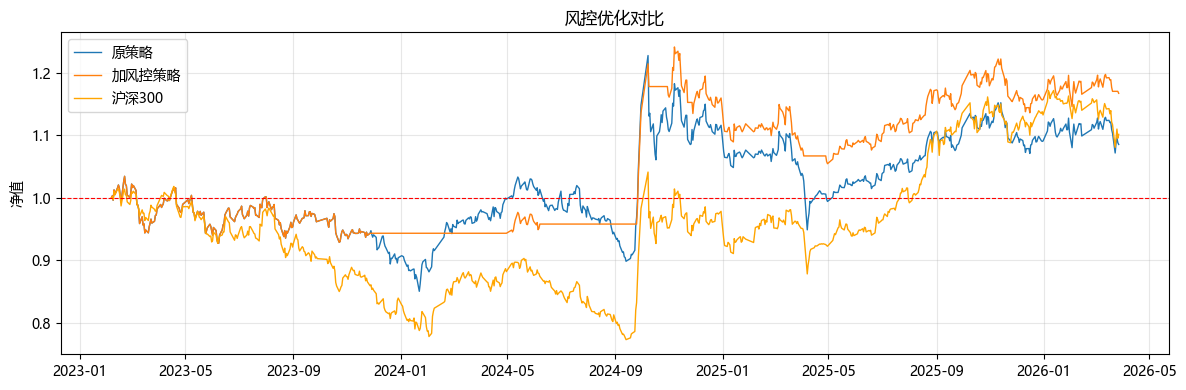

In [17]:
# 计算加风控后的指标
total_return2 = portfolio2.iloc[-1] - 1
days2 = len(portfolio2)
annual_return2 = (1 + total_return2) ** (252/days2) - 1

rolling_max2 = portfolio2.cummax()
drawdown2 = (portfolio2 - rolling_max2) / rolling_max2
max_drawdown2 = drawdown2.min()

daily_returns2 = portfolio2.pct_change().dropna()
sharpe2 = daily_returns2.mean() / daily_returns2.std() * np.sqrt(252)

print("加风控前 vs 加风控后：")
print(f"{'':15} {'原策略':>10} {'加风控':>10}")
print(f"{'累计收益':15} {total_return:>10.2%} {total_return2:>10.2%}")
print(f"{'年化收益':15} {annual_return:>10.2%} {annual_return2:>10.2%}")
print(f"{'最大回撤':15} {max_drawdown:>10.2%} {max_drawdown2:>10.2%}")
print(f"{'Sharpe':15} {sharpe:>10.4f} {sharpe2:>10.4f}")

# 画对比图
common = portfolio.index.intersection(portfolio2.index)
plt.figure(figsize=(12, 4))
plt.plot(common, portfolio[common], linewidth=1, label="原策略")
plt.plot(common, portfolio2[common], linewidth=1, label="加风控策略")
plt.plot(hs300_norm.index, hs300_norm, linewidth=1, label="沪深300", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("风控优化对比")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 对比不同持仓比例的效果
results = {}

for pct in [0.05, 0.10, 0.20, 0.30]:
    pv = [1.0]
    current = []
    
    for i, date in enumerate(dates[20:], start=20):
        prev_date = dates[i-1]
        
        # 风控：沪深300跌破200日均线空仓
        if date in hs300_close.index and date in hs300_ma200.index:
            if hs300_close.loc[date] < hs300_ma200.loc[date]:
                pv.append(pv[-1])
                current = []
                continue
        
        if date in rebalance_dates:
            factor_row = combined.loc[date]
            current = get_selected_stocks(factor_row, pct)
        
        if len(current) == 0:
            pv.append(pv[-1])
            continue
        
        returns = []
        for code in current:
            if code in close_df.columns:
                try:
                    r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                    if not np.isnan(r):
                        returns.append(r)
                except:
                    continue
        
        if len(returns) == 0:
            pv.append(pv[-1])
            continue
        
        daily_return = np.mean(returns)
        if daily_return < -0.03:
            daily_return = -0.03
            current = []
        if date in rebalance_dates:
            daily_return -= cost
        
        pv.append(pv[-1] * (1 + daily_return))
    
    s = pd.Series(pv, index=dates[19:])
    dr = s.pct_change().dropna()
    sharpe = dr.mean() / dr.std() * np.sqrt(252)
    ret = s.iloc[-1] - 1
    dd = ((s - s.cummax()) / s.cummax()).min()
    results[pct] = {"累计收益": ret, "Sharpe": sharpe, "最大回撤": dd}
    print(f"持仓{pct:.0%}：累计收益{ret:.2%}  Sharpe {sharpe:.4f}  最大回撤{dd:.2%}")

持仓5%：累计收益11.26%  Sharpe 0.2963  最大回撤-17.19%
持仓10%：累计收益8.50%  Sharpe 0.2532  最大回撤-15.02%
持仓20%：累计收益16.75%  Sharpe 0.4341  最大回撤-15.06%
持仓30%：累计收益18.41%  Sharpe 0.4767  最大回撤-14.48%


In [19]:
for pct in [0.40, 0.50]:
    pv = [1.0]
    current = []
    
    for i, date in enumerate(dates[20:], start=20):
        prev_date = dates[i-1]
        
        if date in hs300_close.index and date in hs300_ma200.index:
            if hs300_close.loc[date] < hs300_ma200.loc[date]:
                pv.append(pv[-1])
                current = []
                continue
        
        if date in rebalance_dates:
            factor_row = combined.loc[date]
            current = get_selected_stocks(factor_row, pct)
        
        if len(current) == 0:
            pv.append(pv[-1])
            continue
        
        returns = []
        for code in current:
            if code in close_df.columns:
                try:
                    r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                    if not np.isnan(r):
                        returns.append(r)
                except:
                    continue
        
        if len(returns) == 0:
            pv.append(pv[-1])
            continue
        
        daily_return = np.mean(returns)
        if daily_return < -0.03:
            daily_return = -0.03
            current = []
        if date in rebalance_dates:
            daily_return -= cost
        
        pv.append(pv[-1] * (1 + daily_return))
    
    s = pd.Series(pv, index=dates[19:])
    dr = s.pct_change().dropna()
    sharpe = dr.mean() / dr.std() * np.sqrt(252)
    ret = s.iloc[-1] - 1
    dd = ((s - s.cummax()) / s.cummax()).min()
    print(f"持仓{pct:.0%}：累计收益{ret:.2%}  Sharpe {sharpe:.4f}  最大回撤{dd:.2%}")

持仓40%：累计收益24.73%  Sharpe 0.6061  最大回撤-12.52%
持仓50%：累计收益27.73%  Sharpe 0.6784  最大回撤-11.60%


In [21]:
for pct in [0.60, 0.70]:
    pv = [1.0]
    current = []
    
    for i, date in enumerate(dates[20:], start=20):
        prev_date = dates[i-1]
        
        if date in hs300_close.index and date in hs300_ma200.index:
            if hs300_close.loc[date] < hs300_ma200.loc[date]:
                pv.append(pv[-1])
                current = []
                continue
        
        if date in rebalance_dates:
            factor_row = combined.loc[date]
            current = get_selected_stocks(factor_row, pct)
        
        if len(current) == 0:
            pv.append(pv[-1])
            continue
        
        returns = []
        for code in current:
            if code in close_df.columns:
                try:
                    r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                    if not np.isnan(r):
                        returns.append(r)
                except:
                    continue
        
        if len(returns) == 0:
            pv.append(pv[-1])
            continue
        
        daily_return = np.mean(returns)
        if daily_return < -0.03:
            daily_return = -0.03
            current = []
        if date in rebalance_dates:
            daily_return -= cost
        
        pv.append(pv[-1] * (1 + daily_return))
    
    s = pd.Series(pv, index=dates[19:])
    dr = s.pct_change().dropna()
    sharpe = dr.mean() / dr.std() * np.sqrt(252)
    ret = s.iloc[-1] - 1
    dd = ((s - s.cummax()) / s.cummax()).min()
    print(f"持仓{pct:.0%}：累计收益{ret:.2%}  Sharpe {sharpe:.4f}  最大回撤{dd:.2%}")

持仓60%：累计收益30.89%  Sharpe 0.7445  最大回撤-11.59%
持仓70%：累计收益33.26%  Sharpe 0.7872  最大回撤-11.13%


In [23]:
for pct in [0.80, 0.90]:
    pv = [1.0]
    current = []
    
    for i, date in enumerate(dates[20:], start=20):
        prev_date = dates[i-1]
        
        if date in hs300_close.index and date in hs300_ma200.index:
            if hs300_close.loc[date] < hs300_ma200.loc[date]:
                pv.append(pv[-1])
                current = []
                continue
        
        if date in rebalance_dates:
            factor_row = combined.loc[date]
            current = get_selected_stocks(factor_row, pct)
        
        if len(current) == 0:
            pv.append(pv[-1])
            continue
        
        returns = []
        for code in current:
            if code in close_df.columns:
                try:
                    r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                    if not np.isnan(r):
                        returns.append(r)
                except:
                    continue
        
        if len(returns) == 0:
            pv.append(pv[-1])
            continue
        
        daily_return = np.mean(returns)
        if daily_return < -0.03:
            daily_return = -0.03
            current = []
        if date in rebalance_dates:
            daily_return -= cost
        
        pv.append(pv[-1] * (1 + daily_return))
    
    s = pd.Series(pv, index=dates[19:])
    dr = s.pct_change().dropna()
    sharpe = dr.mean() / dr.std() * np.sqrt(252)
    ret = s.iloc[-1] - 1
    dd = ((s - s.cummax()) / s.cummax()).min()
    print(f"持仓{pct:.0%}：累计收益{ret:.2%}  Sharpe {sharpe:.4f}  最大回撤{dd:.2%}")

持仓80%：累计收益36.00%  Sharpe 0.8313  最大回撤-11.51%
持仓90%：累计收益41.32%  Sharpe 0.9119  最大回撤-11.89%


In [25]:
for pct in [1.0]:
    pv = [1.0]
    current = []
    
    for i, date in enumerate(dates[20:], start=20):
        prev_date = dates[i-1]
        
        if date in hs300_close.index and date in hs300_ma200.index:
            if hs300_close.loc[date] < hs300_ma200.loc[date]:
                pv.append(pv[-1])
                current = []
                continue
        
        if date in rebalance_dates:
            factor_row = combined.loc[date]
            current = get_selected_stocks(factor_row, pct)
        
        if len(current) == 0:
            pv.append(pv[-1])
            continue
        
        returns = []
        for code in current:
            if code in close_df.columns:
                try:
                    r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                    if not np.isnan(r):
                        returns.append(r)
                except:
                    continue
        
        if len(returns) == 0:
            pv.append(pv[-1])
            continue
        
        daily_return = np.mean(returns)
        if daily_return < -0.03:
            daily_return = -0.03
            current = []
        if date in rebalance_dates:
            daily_return -= cost
        
        pv.append(pv[-1] * (1 + daily_return))
    
    s = pd.Series(pv, index=dates[19:])
    dr = s.pct_change().dropna()
    sharpe = dr.mean() / dr.std() * np.sqrt(252)
    ret = s.iloc[-1] - 1
    dd = ((s - s.cummax()) / s.cummax()).min()
    print(f"持仓{pct:.0%}：累计收益{ret:.2%}  Sharpe {sharpe:.4f}  最大回撤{dd:.2%}")

持仓100%：累计收益50.64%  Sharpe 1.0259  最大回撤-12.77%


In [26]:
# 情况一：只有风控，不选股（买全部股票）
pv_timing = [1.0]

for i, date in enumerate(dates[20:], start=20):
    prev_date = dates[i-1]
    
    # 只用风控决定空仓还是满仓
    if date in hs300_close.index and date in hs300_ma200.index:
        if hs300_close.loc[date] < hs300_ma200.loc[date]:
            pv_timing.append(pv_timing[-1])
            continue
    
    # 满仓买全部股票
    returns = []
    for code in close_df.columns:
        try:
            r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
            if not np.isnan(r):
                returns.append(r)
        except:
            continue
    
    if len(returns) == 0:
        pv_timing.append(pv_timing[-1])
        continue
    
    daily_return = np.mean(returns)
    pv_timing.append(pv_timing[-1] * (1 + daily_return))

s_timing = pd.Series(pv_timing, index=dates[19:])
ret_timing = s_timing.iloc[-1] - 1
dr_timing = s_timing.pct_change().dropna()
sharpe_timing = dr_timing.mean() / dr_timing.std() * np.sqrt(252)
dd_timing = ((s_timing - s_timing.cummax()) / s_timing.cummax()).min()

print(f"只有风控（择时）：累计收益{ret_timing:.2%}  Sharpe {sharpe_timing:.4f}  最大回撤{dd_timing:.2%}")

只有风控（择时）：累计收益65.28%  Sharpe 1.1479  最大回撤-11.97%


In [27]:
# 情况二：只有选股，没有风控
pv_selection = [1.0]
current_stocks = []

for i, date in enumerate(dates[20:], start=20):
    prev_date = dates[i-1]
    
    # 只用因子选股，不加风控
    if date in rebalance_dates:
        factor_row = combined.loc[date]
        current_stocks = get_selected_stocks(factor_row, 0.2)
    
    if len(current_stocks) == 0:
        pv_selection.append(pv_selection[-1])
        continue
    
    returns = []
    for code in current_stocks:
        if code in close_df.columns:
            try:
                r = close_df.loc[date, code] / close_df.loc[prev_date, code] - 1
                if not np.isnan(r):
                    returns.append(r)
            except:
                continue
    
    if len(returns) == 0:
        pv_selection.append(pv_selection[-1])
        continue
    
    daily_return = np.mean(returns)
    if date in rebalance_dates:
        daily_return -= cost
    pv_selection.append(pv_selection[-1] * (1 + daily_return))

s_selection = pd.Series(pv_selection, index=dates[19:])
ret_selection = s_selection.iloc[-1] - 1
dr_selection = s_selection.pct_change().dropna()
sharpe_selection = dr_selection.mean() / dr_selection.std() * np.sqrt(252)
dd_selection = ((s_selection - s_selection.cummax()) / s_selection.cummax()).min()

print(f"只有选股（无风控）：累计收益{ret_selection:.2%}  Sharpe {sharpe_selection:.4f}  最大回撤{dd_selection:.2%}")

只有选股（无风控）：累计收益8.56%  Sharpe 0.2423  最大回撤-22.73%


收益归因分析：
                           累计收益     Sharpe       最大回撤
沪深300基准                  10.17%          —          —
只有选股（无风控）                 8.56%     0.2423    -22.73%
只有风控（择时）                 65.28%     1.1479    -11.97%
完整策略（选股+风控）              16.75%     0.4341    -15.06%


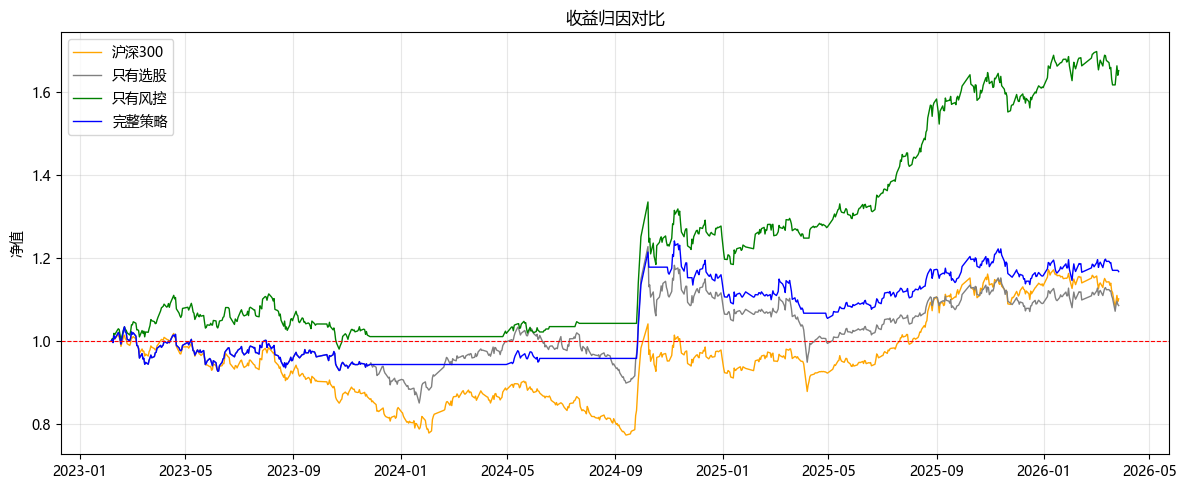

In [28]:
# 汇总对比
print("收益归因分析：")
print(f"{'':20} {'累计收益':>10} {'Sharpe':>10} {'最大回撤':>10}")
print(f"{'沪深300基准':20} {hs300_return:>10.2%} {'—':>10} {'—':>10}")
print(f"{'只有选股（无风控）':20} {ret_selection:>10.2%} {sharpe_selection:>10.4f} {dd_selection:>10.2%}")
print(f"{'只有风控（择时）':20} {ret_timing:>10.2%} {sharpe_timing:>10.4f} {dd_timing:>10.2%}")
print(f"{'完整策略（选股+风控）':20} {total_return2:>10.2%} {sharpe2:>10.4f} {max_drawdown2:>10.2%}")

# 画对比图
common = s_timing.index.intersection(s_selection.index).intersection(portfolio2.index)
plt.figure(figsize=(12, 5))
plt.plot(hs300_norm.index, hs300_norm, linewidth=1, label="沪深300", color="orange")
plt.plot(common, s_selection[common], linewidth=1, label="只有选股", color="gray")
plt.plot(common, s_timing[common], linewidth=1, label="只有风控", color="green")
plt.plot(common, portfolio2[common], linewidth=1, label="完整策略", color="blue")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("收益归因对比")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()